Tamanho da imagem :  (256, 256)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


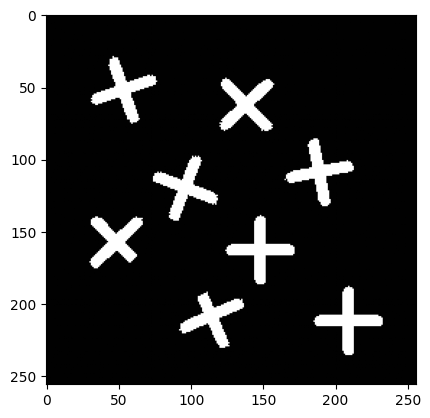

In [183]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math


img = cv2.imread("art8.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray', vmin=0, vmax=255);

print('Tamanho da imagem : ',img.shape)
# convertendo para 300dpi

print(img)




linhas = img.shape[0]
colunas = img.shape[1];



In [184]:

def contar_objetos(img,linhas,colunas,cor_fundo):
    numero_objeto = 0
    lista_equivalencia = set()
    
    nova_imagem = np.zeros( (linhas,colunas), dtype=np.uint8)
    for i in range(0, linhas-1):
        for j in range(0, colunas-1):
            if img[i,j] != cor_fundo:
                set_aux = set()
                
                ''' Busca V8 '''
                for k in range(-1,2):
                    for l in range(-1,2):
                        ni, nj = i+k, j+l
                        if 0 <= ni < linhas and 0 <= nj < colunas:
                            if nova_imagem[ni, nj] != 0:
                                set_aux.add(nova_imagem[ni, nj])
                if len(set_aux) > 0:
                    set_objetos = sorted(set_aux)
                    nova_imagem[i,j] = set_objetos[0]
                    lista_equivalencia.add(frozenset(set_objetos))
                else:
                    numero_objeto += 1
                    nova_imagem[i,j] = numero_objeto
                    lista_equivalencia.add(frozenset(set([numero_objeto])))
                    
                    
                    
    def find(rep, x):
        while rep[x] != x:
            rep[x] = rep[rep[x]]
            x = rep[x]
        return x

    def union(rep, x, y):
        rx, ry = find(rep, x), find(rep, y)
        if rx != ry:
            rep[max(rx, ry)] = min(rx, ry)

    representante = {r: r for r in range(1, numero_objeto + 1)}

    for grupo in lista_equivalencia:
        vals = sorted(int(x) for x in grupo)
        for i in range(1, len(vals)):
            union(representante, vals[0], vals[i])

    num_objetos = len(set(find(representante, r) for r in representante))
    print("Número de objetos:", num_objetos)
                        


In [186]:
contar_objetos(img,linhas,colunas,1)

Número de objetos: 8


Tamanho da imagem :  (256, 256)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


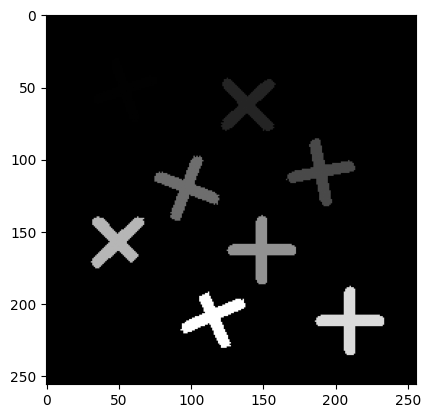

In [187]:
img2 = cv2.imread("art8lab1.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img2, cmap='gray', vmin=0, vmax=255);

print('Tamanho da imagem : ',img2.shape)
print(img2)




linhas = img.shape[0]
colunas = img.shape[1];

In [188]:
contar_objetos(img2,linhas,colunas,0)

Número de objetos: 8


Tamanho da imagem :  (256, 256)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


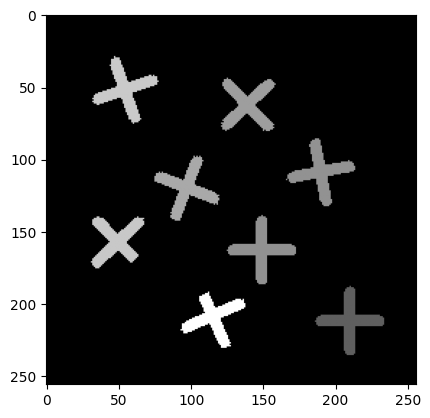

In [189]:
img3 = cv2.imread("art8lab2.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img3, cmap='gray', vmin=0, vmax=255);

print('Tamanho da imagem : ',img3.shape)
print(img3)




linhas = img.shape[0]
colunas = img.shape[1];

In [190]:
contar_objetos(img3,linhas,colunas,0)

Número de objetos: 8


Tamanho da imagem :  (260, 200)
[[226 226 222 ... 226 230 229]
 [225 225 222 ... 226 229 236]
 [222 222 226 ... 225 229 230]
 ...
 [167 167 160 ... 223 225 227]
 [183 183 178 ... 219 220 223]
 [216 216 212 ... 219 219 225]]


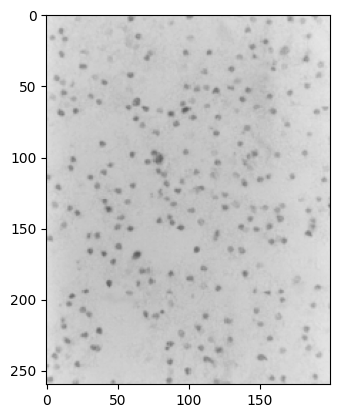

In [191]:
img4 = cv2.imread("clc3.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img4, cmap='gray', vmin=0, vmax=255);

print('Tamanho da imagem : ',img4.shape)
print(img4)

linhas= img4.shape[0]
colunas = img4.shape[1];

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [  0   0   0 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


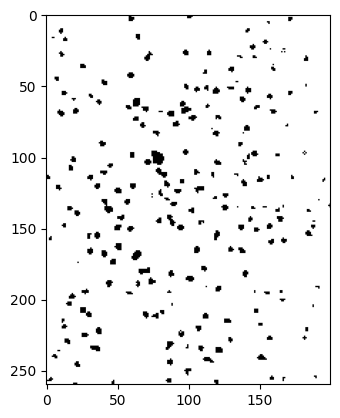

In [195]:
def binarizar(img,linhas,colunas,threshold):
    nova_imagem = np.zeros( (linhas,colunas), dtype=np.uint8)
    for i in range(0,linhas):
        for j in range(0,colunas):
            if img[i,j] > threshold:
                nova_imagem[i,j] = 0    
            else: 
                nova_imagem[i,j] = 255
    return nova_imagem


img4 = binarizar(img4,linhas,colunas,167)
plt.imshow(img4, cmap='gray', vmin=0, vmax=255);
print(img4)

In [196]:
contar_objetos(img4,linhas,colunas,255)

Número de objetos: 216


Tamanho da imagem :  (260, 200)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


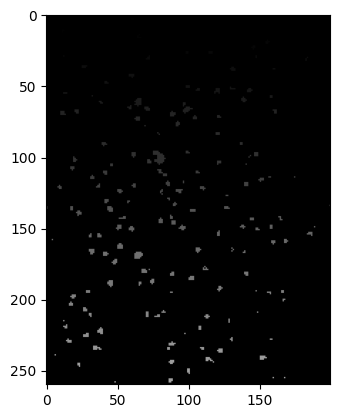

In [197]:
img5 = cv2.imread("clc3lab1.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img5, cmap='gray', vmin=0, vmax=255);

print('Tamanho da imagem : ',img5.shape)
print(img5)

linhas= img5.shape[0]
colunas = img5.shape[1];



[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


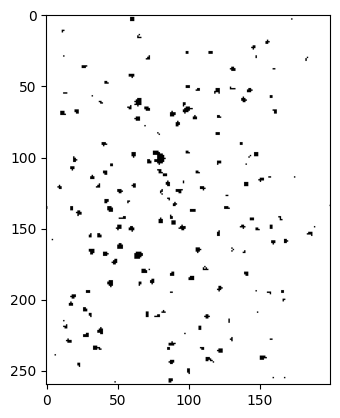

In [198]:
img5 = binarizar(img5,linhas,colunas, 0)
plt.imshow(img5, cmap='gray', vmin=0, vmax=255);
print(img5)

In [200]:



contar_objetos(img5,linhas,colunas,255)

Número de objetos: 162


Tamanho da imagem :  (260, 200)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


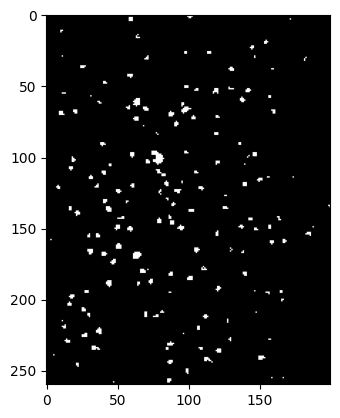

In [181]:
img6 = cv2.imread("clc3thr1.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img6, cmap='gray', vmin=0, vmax=255);

print('Tamanho da imagem : ',img6.shape)
print(img6)

linhas= img6.shape[0]
colunas = img6.shape[1]

In [182]:
contar_objetos(img5,linhas,colunas,255)

Número de objetos: 162
